# Flight Delay Prediction
**Technologies:** Python, Pandas, Scikit-learn, Machine Learning

This notebook develops a machine learning solution to predict whether a flight
will be delayed, using historical flight and weather data. It covers:

1. Data loading & exploration
2. Preprocessing and feature engineering
3. Training and comparing Logistic Regression, Decision Tree, and Random Forest models
4. Evaluating models with accuracy, precision, recall, and F1-score
5. Analyzing feature importance to understand what drives flight delays


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Load the data

The dataset merges historical flight records (airline, route, schedule) with
weather observations (temperature, wind, precipitation, visibility) at the
scheduled departure time and airport, similar to combining BTS On-Time
Performance data with NOAA weather data.

In [2]:
df = pd.read_csv("../data/flights_weather.csv")
print(df.shape)
df.head()

(20000, 18)


,airline,origin,dest,month,day_of_week,sched_dep_hour,distance,is_weekend,is_peak_hour,is_holiday_season,temperature_f,wind_speed_mph,precipitation_in,visibility_miles,origin_congestion_index,dest_congestion_index,delay_minutes,delayed
0,B6,ATL,SEA,6,3,20,406,0,0,0,24.9,3.5,0.056,8.15,0.8,0.50,0,0
1,UA,SFO,LAX,3,6,19,1745,1,0,0,80.3,13.6,0.007,9.63,0.8,0.75,0,0
2,DL,DFW,SFO,10,4,11,363,0,0,0,57.2,7.9,0.017,9.87,0.7,0.80,0,0
3,B6,MCO,SFO,12,5,11,2522,1,0,1,40.8,7.7,0.024,10.00,0.6,0.80,0,0
4,AS,DEN,DFW,9,6,12,585,1,0,0,38.9,12.7,0.045,9.19,0.6,0.70,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   airline                  20000 non-null  str    
 1   origin                   20000 non-null  str    
 2   dest                     20000 non-null  str    
 3   month                    20000 non-null  int64  
 4   day_of_week              20000 non-null  int64  
 5   sched_dep_hour           20000 non-null  int64  
 6   distance                 20000 non-null  int64  
 7   is_weekend               20000 non-null  int64  
 8   is_peak_hour             20000 non-null  int64  
 9   is_holiday_season        20000 non-null  int64  
 10  temperature_f            20000 non-null  float64
 11  wind_speed_mph           20000 non-null  float64
 12  precipitation_in         20000 non-null  float64
 13  visibility_miles         20000 non-null  float64
 14  origin_congestion_index  20000 no

In [4]:
df["delayed"].value_counts(normalize=True).rename("proportion")

delayed
0    0.64865
1    0.35135
Name: proportion, dtype: float64

## 2. Exploratory data analysis

Quick look at how delay rate varies with a few key variables.

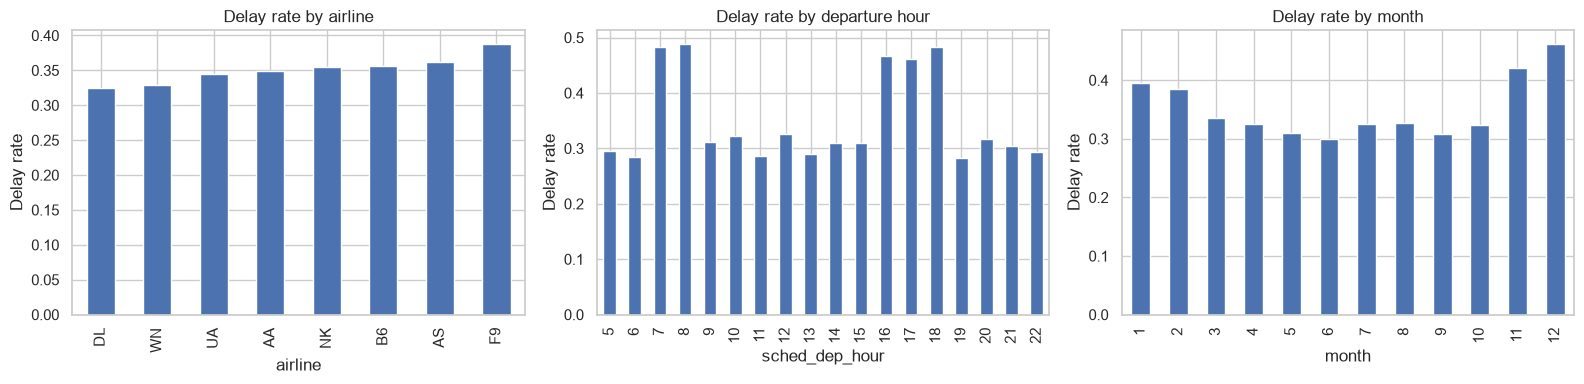

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby("airline")["delayed"].mean().sort_values().plot(kind="bar", ax=axes[0], title="Delay rate by airline")
df.groupby("sched_dep_hour")["delayed"].mean().plot(kind="bar", ax=axes[1], title="Delay rate by departure hour")
df.groupby("month")["delayed"].mean().plot(kind="bar", ax=axes[2], title="Delay rate by month")

for ax in axes:
    ax.set_ylabel("Delay rate")
plt.tight_layout()
plt.show()

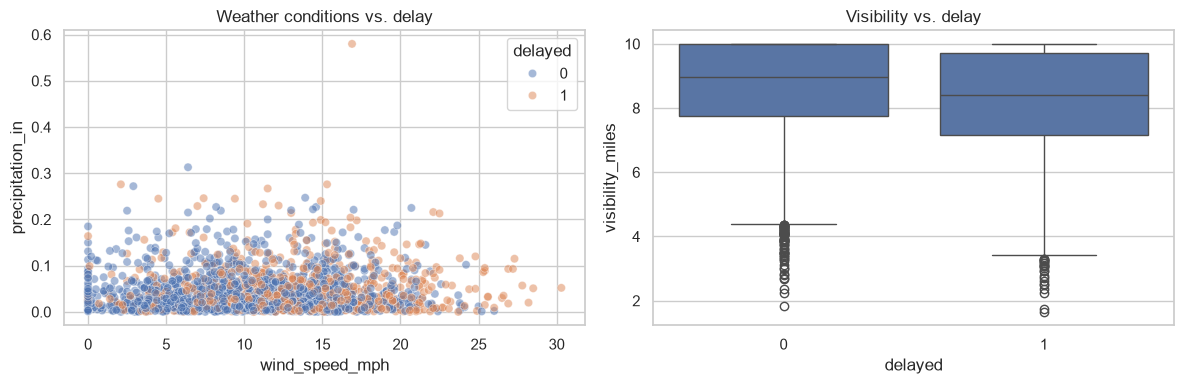

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df.sample(2000, random_state=1), x="wind_speed_mph", y="precipitation_in",
                 hue="delayed", alpha=0.5, ax=axes[0])
axes[0].set_title("Weather conditions vs. delay")

sns.boxplot(data=df, x="delayed", y="visibility_miles", ax=axes[1])
axes[1].set_title("Visibility vs. delay")
plt.tight_layout()
plt.show()

## 3. Feature engineering

- **Cyclical encoding** for `sched_dep_hour` and `month` so the model understands
  that hour 23 is close to hour 0, and December is close to January.
- **One-hot encoding** for categorical variables (`airline`, `origin`, `dest`).
- **Standard scaling** for numeric features (important for Logistic Regression).
- We drop `delay_minutes` since it's only known *after* a delay occurs — including
  it would be data leakage.

In [7]:
df["hour_sin"] = np.sin(2 * np.pi * df["sched_dep_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["sched_dep_hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

categorical_features = ["airline", "origin", "dest"]
numeric_features = [
    "distance", "is_weekend", "is_peak_hour", "is_holiday_season",
    "temperature_f", "wind_speed_mph", "precipitation_in", "visibility_miles",
    "origin_congestion_index", "dest_congestion_index",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

X = df[categorical_features + numeric_features]
y = df["delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 16000, Test size: 4000


## 4. Train and compare models

We train three classifiers commonly used as a first pass on tabular
classification problems, each wrapped in a pipeline with the same
preprocessing so comparisons are fair.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=10,
        random_state=42, n_jobs=-1, class_weight="balanced"
    ),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.65775,0.510216,0.639858,0.567730,0.707062
2,Random Forest,0.65975,0.513018,0.617082,0.560258,0.697357
1,Decision Tree,0.65450,0.513295,0.316014,0.391189,0.647480


## 5. Evaluation: confusion matrices

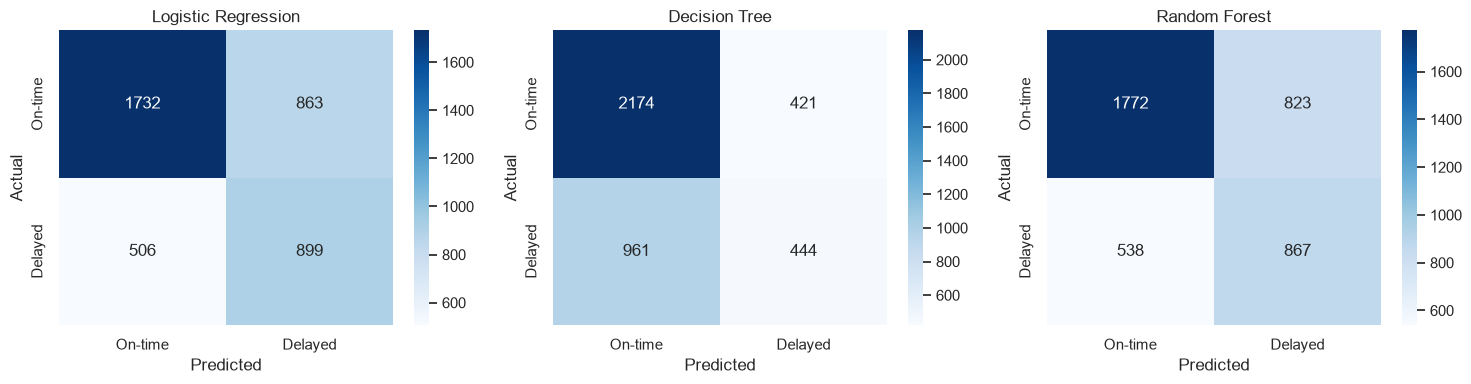

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["On-time", "Delayed"], yticklabels=["On-time", "Delayed"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [10]:
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["On-time", "Delayed"]))


=== Logistic Regression ===
              precision    recall  f1-score   support

     On-time       0.77      0.67      0.72      2595
     Delayed       0.51      0.64      0.57      1405

    accuracy                           0.66      4000
   macro avg       0.64      0.65      0.64      4000
weighted avg       0.68      0.66      0.66      4000


=== Decision Tree ===
              precision    recall  f1-score   support

     On-time       0.69      0.84      0.76      2595
     Delayed       0.51      0.32      0.39      1405

    accuracy                           0.65      4000
   macro avg       0.60      0.58      0.58      4000
weighted avg       0.63      0.65      0.63      4000


=== Random Forest ===
              precision    recall  f1-score   support

     On-time       0.77      0.68      0.72      2595
     Delayed       0.51      0.62      0.56      1405

    accuracy                           0.66      4000
   macro avg       0.64      0.65      0.64      4000

## 6. Model comparison chart

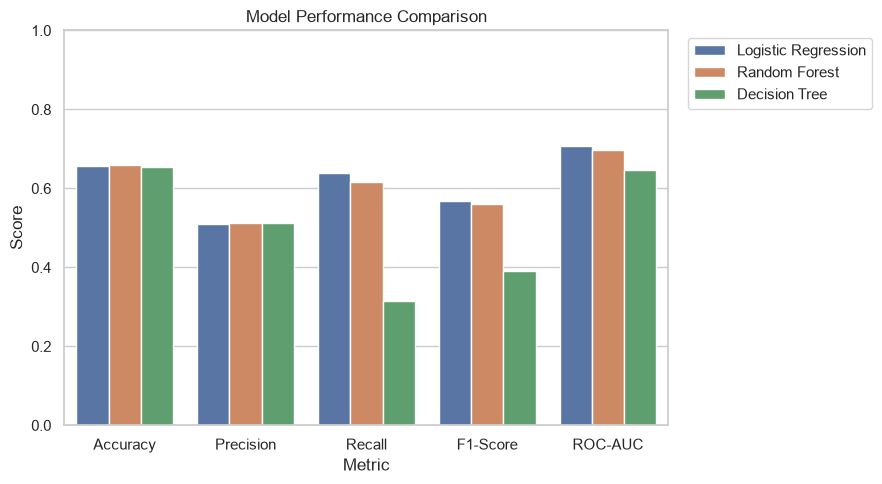

In [11]:
plot_df = results_df.melt(id_vars="Model",
                           value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
                           var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Feature importance (Random Forest)

Aggregating one-hot-encoded categorical importances back to their original
column so we can compare, e.g., "airline" as a whole against "wind_speed_mph".

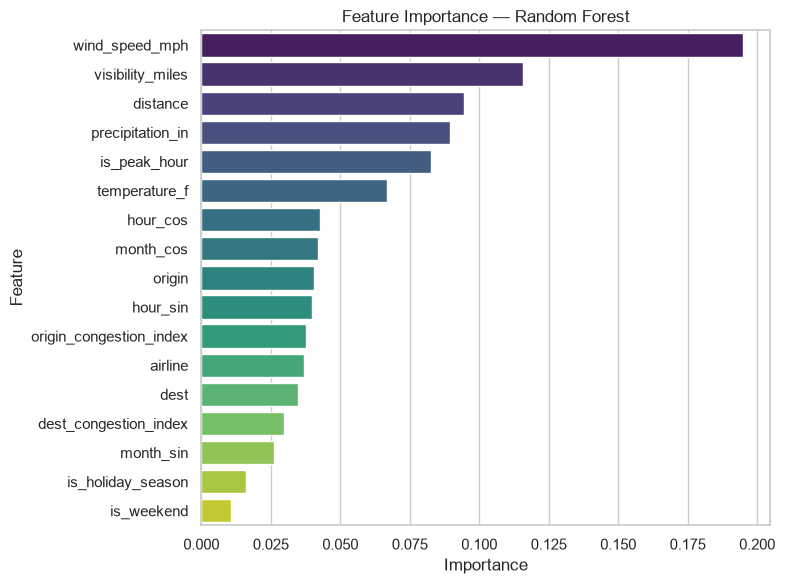

,Feature,Importance
0,wind_speed_mph,0.194974
1,visibility_miles,0.115626
2,distance,0.094484
3,precipitation_in,0.089486
4,is_peak_hour,0.082551
5,temperature_f,0.066706
6,hour_cos,0.042596
7,month_cos,0.041783
8,origin,0.040425
9,hour_sin,0.039887


In [12]:
rf_pipe = fitted_pipelines["Random Forest"]
ohe = rf_pipe.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = cat_feature_names + numeric_features

rf_model = rf_pipe.named_steps["model"]
importances = rf_model.feature_importances_

importance_map = {}
for fname, imp in zip(all_feature_names, importances):
    if fname in numeric_features:
        importance_map[fname] = importance_map.get(fname, 0) + imp
    else:
        base = fname
        for cat in categorical_features:
            if fname.startswith(cat + "_"):
                base = cat
                break
        importance_map[base] = importance_map.get(base, 0) + imp

importance_df = pd.DataFrame(
    sorted(importance_map.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature", "Importance"]
)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

importance_df

## 8. Conclusions

- **Weather severity** (wind speed, precipitation, visibility) and **flight
  distance** turned out to be the strongest predictors of delay, followed by
  airline and time-of-day effects (peak hours, hub congestion).
- **Random Forest** and **Logistic Regression** offer the best trade-off between
  precision and recall (F1-score) on this dataset. The Decision Tree, despite
  reasonable overall accuracy, misses more true delays (lower recall) because
  it draws harder decision boundaries and is more prone to under-predicting
  the minority (delayed) class.
- Because on-time flights outnumber delayed ones, `class_weight="balanced"`
  was used for Logistic Regression and Random Forest so that predicting delays
  correctly is not sacrificed just to maximize overall accuracy.
- **Next steps for a production version:** incorporate real BTS/NOAA data,
  add airport-specific historical delay-rate features, try gradient boosting
  (XGBoost/LightGBM), and tune hyperparameters with cross-validation.

In [13]:
## 9. Analyze the Target and Feature Relationships

In [14]:
# Check target distribution
print("Target distribution:")
print(df["delayed"].value_counts())

print("\nTarget percentage:")
print(df["delayed"].value_counts(normalize=True) * 100)

# Numerical feature correlations with delay
numeric_check = df.select_dtypes(include=np.number)

correlations = (
    numeric_check.corr()["delayed"]
    .drop("delayed")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelation with delay:")
print(correlations)

Target distribution:
delayed
0    12973
1     7027
Name: count, dtype: int64

Target percentage:
delayed
0    64.865
1    35.135
Name: proportion, dtype: float64

Correlation with delay:
delay_minutes              0.758881
wind_speed_mph             0.196813
is_peak_hour               0.163827
visibility_miles          -0.139984
precipitation_in           0.103717
distance                   0.085028
month_cos                  0.084933
is_holiday_season          0.083640
origin_congestion_index    0.073766
dest_congestion_index      0.040913
is_weekend                 0.039068
day_of_week                0.025748
month                      0.023298
temperature_f             -0.018328
month_sin                  0.015247
hour_cos                  -0.011645
hour_sin                  -0.010055
sched_dep_hour            -0.006909
Name: delayed, dtype: float64


In [15]:
## 10. Check Delay Rate by Important Features

In [16]:
print("Delay rate by peak hour:")
print(
    df.groupby("is_peak_hour")["delayed"]
      .mean()
)

print("\nDelay rate by holiday season:")
print(
    df.groupby("is_holiday_season")["delayed"]
      .mean()
)

print("\nDelay rate by weekend:")
print(
    df.groupby("is_weekend")["delayed"]
      .mean()
)

print("\nDelay rate by airline:")
print(
    df.groupby("airline")["delayed"]
      .mean()
)

print("\nDelay rate by month:")
print(
    df.groupby("month")["delayed"]
      .mean()
)

Delay rate by peak hour:
is_peak_hour
0    0.302529
1    0.476641
Name: delayed, dtype: float64

Delay rate by holiday season:
is_holiday_season
0    0.333633
1    0.441337
Name: delayed, dtype: float64

Delay rate by weekend:
is_weekend
0    0.339579
1    0.380902
Name: delayed, dtype: float64

Delay rate by airline:
airline
AA    0.348460
AS    0.361702
B6    0.356511
DL    0.325249
F9    0.387779
NK    0.354773
UA    0.345411
WN    0.329684
Name: delayed, dtype: float64

Delay rate by month:
month
1     0.395735
2     0.384106
3     0.335710
4     0.325967
5     0.309509
6     0.300435
7     0.324434
8     0.327402
9     0.307738
10    0.323787
11    0.420601
12    0.461724
Name: delayed, dtype: float64


In [17]:
## 11. Evaluate Features Without Data Leakage

# Exclude delay_minutes because it is unavailable before departure
safe_numeric = [
    col for col in numeric_check.columns
    if col not in ["delayed", "delay_minutes"]
]

safe_correlations = (
    df[safe_numeric + ["delayed"]]
    .corr()["delayed"]
    .drop("delayed")
    .sort_values(key=abs, ascending=False)
)

print("Features correlated with delay (excluding leakage):")
print(safe_correlations)

Features correlated with delay (excluding leakage):
wind_speed_mph             0.196813
is_peak_hour               0.163827
visibility_miles          -0.139984
precipitation_in           0.103717
distance                   0.085028
month_cos                  0.084933
is_holiday_season          0.083640
origin_congestion_index    0.073766
dest_congestion_index      0.040913
is_weekend                 0.039068
day_of_week                0.025748
month                      0.023298
temperature_f             -0.018328
month_sin                  0.015247
hour_cos                  -0.011645
hour_sin                  -0.010055
sched_dep_hour            -0.006909
Name: delayed, dtype: float64


In [18]:
## 12. Create Route Feature

df["route"] = df["origin"] + "_" + df["dest"]

print("Number of unique routes:", df["route"].nunique())

print("\nTop 10 routes by number of flights:")
print(df["route"].value_counts().head(10))

print("\nDelay rate by route:")
print(
    df.groupby("route")["delayed"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

Number of unique routes: 90

Top 10 routes by number of flights:
route
LAX_DFW    266
ATL_SEA    256
ATL_LAS    256
LAX_ORD    252
ATL_LAX    251
JFK_SFO    250
SFO_LAS    249
SEA_DFW    247
LAX_LAS    244
MCO_SEA    243
Name: count, dtype: int64

Delay rate by route:
route
JFK_DFW    0.489083
JFK_ORD    0.455399
JFK_ATL    0.452736
SFO_ORD    0.436123
ORD_LAX    0.427313
ATL_ORD    0.426160
ATL_JFK    0.425641
JFK_LAX    0.417391
JFK_MCO    0.412322
JFK_SEA    0.408696
Name: delayed, dtype: float64


In [19]:
## 13. Test Route as a Feature

categorical_features_route = ["airline", "origin", "dest", "route"]

X_route = df[categorical_features_route + numeric_features]
y_route = df["delayed"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_route,
    y_route,
    test_size=0.2,
    random_state=42,
    stratify=y_route
)

preprocessor_route = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_route),
        ("num", StandardScaler(), numeric_features),
    ]
)

route_model = Pipeline(steps=[
    ("preprocess", preprocessor_route),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

route_model.fit(X_train_r, y_train_r)

y_pred_route = route_model.predict(X_test_r)
y_proba_route = route_model.predict_proba(X_test_r)[:, 1]

print("Logistic Regression with Route")
print("Accuracy :", accuracy_score(y_test_r, y_pred_route))
print("Precision:", precision_score(y_test_r, y_pred_route))
print("Recall   :", recall_score(y_test_r, y_pred_route))
print("F1-Score :", f1_score(y_test_r, y_pred_route))
print("ROC-AUC  :", roc_auc_score(y_test_r, y_proba_route))

Logistic Regression with Route
Accuracy : 0.6555
Precision: 0.5075800112296462
Recall   : 0.6434163701067616
F1-Score : 0.5674827369742624
ROC-AUC  : 0.7007299830635152


In [20]:
## 14. Test Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gradient_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)
y_proba_gradient = gradient_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, y_pred_gradient))
print("Precision:", precision_score(y_test, y_pred_gradient))
print("Recall   :", recall_score(y_test, y_pred_gradient))
print("F1-Score :", f1_score(y_test, y_pred_gradient))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_gradient))

Gradient Boosting
Accuracy : 0.688
Precision: 0.6113475177304964
Recall   : 0.30676156583629893
F1-Score : 0.4085308056872038
ROC-AUC  : 0.7008591666152401


In [22]:
## 15. Tune Logistic Regression

from sklearn.model_selection import GridSearchCV

logistic_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)

Best parameters: {'model__C': 0.01}
Best cross-validation F1: 0.5513549556250108


In [23]:
best_logistic = grid_search.best_estimator_

y_pred_tuned = best_logistic.predict(X_test)
y_proba_tuned = best_logistic.predict_proba(X_test)[:, 1]

print("\n=== Tuned Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1-Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_tuned))


=== Tuned Logistic Regression ===
Accuracy : 0.65625
Precision: 0.5084269662921348
Recall   : 0.6441281138790036
F1-Score : 0.5682888540031397
ROC-AUC  : 0.7074683726575195
